# 02 — Analysis and figures

**The question:**
> *Does an "A" in a New York City restaurant's window mean the same thing whether it was earned at the first, unannounced inspection or only after a re-inspection?*

**How I answer it:** follow each A grade forward to the restaurant's **next unannounced initial inspection** and compare the two routes:

| Route | What happened |
| :-- | :-- |
| **A at initial** | the surprise inspection scored 0-13, so the A was posted straight away |
| **A after re-inspection** | the surprise inspection scored 14+ (a B or C score), and the A came from the re-inspection about a month later |

**Outcome:** did the restaurant **fail** (score 14+) its next surprise inspection? Plus the next score itself.
**Uncertainty:** 95% confidence intervals from a **cluster bootstrap** that resamples whole restaurants (the same restaurant appears many times, so resampling single inspections would make the intervals too narrow).

In [1]:
import sys, json
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.paths import PROCESSED, RESULTS
from src.analysis import (cycle_inspections, build_grade_events, cluster_bootstrap_means,
                          diff_ci, fmt_ci, A_MAX)
from src.plotting_utils import set_style, PALETTE, GROUP_COLORS, save

set_style()
B = 2000          # bootstrap resamples
ROUTES = ["A at initial", "A after re-inspection"]

inspections = pd.read_csv(PROCESSED / "inspections.csv", parse_dates=["inspection_date"])
restaurants = pd.read_csv(PROCESSED / "restaurants.csv")
print(f"{len(inspections):,} inspections of {len(restaurants):,} restaurants")

135,864 inspections of 25,744 restaurants


## 1. Rebuild the inspection cycles

`build_grade_events` (in `src/analysis.py`) keeps scored cycle inspections, finds every A grade, labels its route, and attaches the restaurant's next initial inspection. Rules:
- the re-inspection must be the very next cycle inspection and within **120 days** of the failed initial one (otherwise it isn't the same cycle);
- the "next initial inspection" is the first initial inspection **after the A was posted**.

In [2]:
cyc = cycle_inspections(inspections)
print(cyc["kind"].value_counts(), "\n")

events = build_grade_events(cyc, restaurants.set_index("camis")["boro"])
events["route"] = pd.Categorical(events["route"], ROUTES)
print(events["route"].value_counts(), "\n")
events.head()

kind
Initial Inspection    70147
Re-inspection         34010
Name: count, dtype: int64 

route
A at initial             41297
A after re-inspection    18599
Name: count, dtype: int64 



,camis,boro,route,inspection_date,initial_score,grade_date,next_date,next_score,next_fail,gap_days
0,30075445,BRONX,A at initial,2016-02-18,10.0,2016-02-18,2017-05-18,7.0,0.0,455.0
1,30075445,BRONX,A at initial,2017-05-18,7.0,2017-05-18,2018-05-11,5.0,0.0,358.0
2,30075445,BRONX,A at initial,2018-05-11,5.0,2018-05-11,NaT,NaN,NaN,NaN
3,30112340,BROOKLYN,A at initial,2015-05-07,12.0,2015-05-07,2016-04-12,0.0,0.0,341.0
4,30112340,BROOKLYN,A at initial,2016-04-12,0.0,2016-04-12,2016-10-03,48.0,1.0,174.0


Not every A has a "next" inspection yet: grades posted in 2018 often weren't followed up before the data was extracted (December 2018). Those A grades count for "how A grades are earned" but not for the follow-up comparison.

In [3]:
followed = events.dropna(subset=["next_score"]).copy()
print("A grades with a next initial inspection:", len(followed), "of", len(events))
followed.groupby("route", observed=True).agg(
    n=("camis", "size"), restaurants=("camis", "nunique"),
    initial_score=("initial_score", "mean"), next_score=("next_score", "mean"),
    median_gap_days=("gap_days", "median")).round(1)

A grades with a next initial inspection: 41190 of 59896


,n,restaurants,initial_score,next_score,median_gap_days
route,,,,,
A at initial,26098,16152,9.2,14.4,381.0
A after re-inspection,15092,10043,24.6,18.7,185.0


## 2. How common is each route?

In [4]:
events["after_reinspection"] = (events["route"] == "A after re-inspection").astype(float)
share_all, _ = cluster_bootstrap_means(events, "after_reinspection", B=B)
share_boro, _ = cluster_bootstrap_means(events, "after_reinspection", by="boro", B=B)
print("Share of A grades earned only on re-inspection:",
      fmt_ci(*share_all.loc["all", ["estimate", "ci_low", "ci_high"]], pct=True))
share_boro

Share of A grades earned only on re-inspection: 31.1% (95% CI 30.6% to 31.5%)


,estimate,ci_low,ci_high,n_obs,n_restaurants
boro,,,,,
BRONX,0.282202,0.269875,0.294958,5613,2011
BROOKLYN,0.317208,0.308582,0.325620,14615,5355
MANHATTAN,0.320025,0.313194,0.326982,23820,8781
QUEENS,0.295282,0.286956,0.304305,13797,4868
STATEN ISLAND,0.332521,0.309591,0.355034,2051,777


**About 3 in 10 A grades** were earned only after a failed surprise inspection. The window card looks the same either way.

### Figure 2 — share of A grades earned on re-inspection, by borough

'/home/claude/p1/figures/fig2_share_A_after_reinspection_by_borough.png'

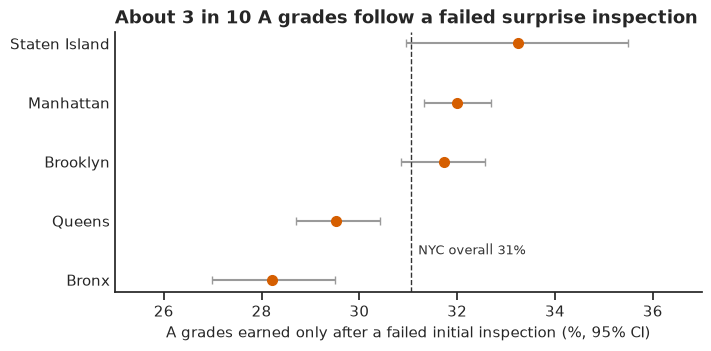

In [5]:
d = share_boro.sort_values("estimate")
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.errorbar(d["estimate"] * 100, d.index.str.title(),
            xerr=[(d["estimate"] - d["ci_low"]) * 100, (d["ci_high"] - d["estimate"]) * 100],
            fmt="o", color=PALETTE["red"], ecolor=PALETTE["grey"], capsize=3, ms=7)
overall = share_all.loc["all", "estimate"] * 100
ax.axvline(overall, color=PALETTE["dark"], ls="--", lw=1)
ax.text(overall + 0.15, 0.5, f"NYC overall {overall:.0f}%", fontsize=9, color=PALETTE["dark"], va="center")
ax.set_xlim(25, 37)
ax.set_xlabel("A grades earned only after a failed initial inspection (%, 95% CI)")
ax.set_title("About 3 in 10 A grades follow a failed surprise inspection")
ax.tick_params(axis="y", length=0)
save(fig, "fig2_share_A_after_reinspection_by_borough")

## 3. Main result: what happens at the next surprise inspection?

In [6]:
fail_sum, fail_draws = cluster_bootstrap_means(followed, "next_fail", by="route", B=B)
score_sum, score_draws = cluster_bootstrap_means(followed, "next_score", by="route", B=B)

fail_diff = diff_ci(fail_draws, "A after re-inspection", "A at initial",
                    fail_sum.loc["A after re-inspection", "estimate"] - fail_sum.loc["A at initial", "estimate"])
score_diff = diff_ci(score_draws, "A after re-inspection", "A at initial",
                     score_sum.loc["A after re-inspection", "estimate"] - score_sum.loc["A at initial", "estimate"])
rr = fail_draws["A after re-inspection"] / fail_draws["A at initial"]
rr_est = fail_sum.loc["A after re-inspection", "estimate"] / fail_sum.loc["A at initial", "estimate"]

for route in ROUTES:
    print(f"{route:24s} fails next surprise inspection: "
          f"{fmt_ci(*fail_sum.loc[route, ['estimate', 'ci_low', 'ci_high']], pct=True)}"
          f" | mean next score {fmt_ci(*score_sum.loc[route, ['estimate', 'ci_low', 'ci_high']])}")
print(f"\nDifference in fail rate: {100*fail_diff['estimate']:.1f} percentage points "
      f"(95% CI {100*fail_diff['ci_low']:.1f} to {100*fail_diff['ci_high']:.1f})")
print(f"Relative risk: {rr_est:.2f} (95% CI {rr.quantile(.025):.2f} to {rr.quantile(.975):.2f})")
print(f"Difference in next score: {fmt_ci(score_diff['estimate'], score_diff['ci_low'], score_diff['ci_high'])} points")

A at initial             fails next surprise inspection: 33.1% (95% CI 32.6% to 33.7%) | mean next score 14.4 (95% CI 14.3 to 14.5)
A after re-inspection    fails next surprise inspection: 51.6% (95% CI 50.8% to 52.4%) | mean next score 18.7 (95% CI 18.5 to 18.9)

Difference in fail rate: 18.5 percentage points (95% CI 17.5 to 19.5)
Relative risk: 1.56 (95% CI 1.52 to 1.59)
Difference in next score: 4.2 (95% CI 4.0 to 4.5) points


### Is it just noise? A permutation test (Week 5)

The bootstrap above already gives intervals far from zero. As a second check, a permutation test needs **independent units**, so it uses one A grade per restaurant (each restaurant's first) and shuffles the route labels 10,000 times.

In [7]:
first = followed.sort_values("grade_date").groupby("camis").head(1)
y = first["next_fail"].to_numpy()
is_re = (first["route"] == "A after re-inspection").to_numpy()
observed = y[is_re].mean() - y[~is_re].mean()

rng = np.random.default_rng(2026)
n_perm = 10_000
perm = np.empty(n_perm)
for k in range(n_perm):
    lab = rng.permutation(is_re)
    perm[k] = y[lab].mean() - y[~lab].mean()
p_value = (np.sum(np.abs(perm) >= abs(observed)) + 1) / (n_perm + 1)
print(f"First A per restaurant: n = {len(first):,}; observed difference = {100*observed:.1f} points")
print(f"Largest shuffled difference: {100*np.abs(perm).max():.1f} points -> p = {p_value:.4f} (the smallest possible with 10,000 shuffles)")

First A per restaurant: n = 18,825; observed difference = 19.2 points
Largest shuffled difference: 3.2 points -> p = 0.0001 (the smallest possible with 10,000 shuffles)


### Figure 1 — the centrepiece

'/home/claude/p1/figures/fig1_next_inspection_fail_rate.png'

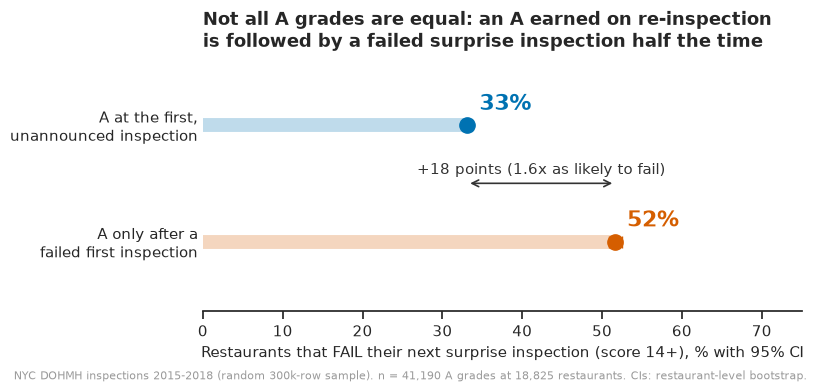

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
yy = {"A at initial": 1, "A after re-inspection": 0}
for route in ROUTES:
    est, lo, hi = fail_sum.loc[route, ["estimate", "ci_low", "ci_high"]] * 100
    color = GROUP_COLORS[route]
    ax.plot([0, est], [yy[route]] * 2, color=color, lw=10, alpha=.25, solid_capstyle="butt")
    ax.errorbar(est, yy[route], xerr=[[est - lo], [hi - est]], fmt="o", color=color,
                ms=11, capsize=4, lw=2)
    ax.text(est + 1.5, yy[route] + .18, f"{est:.0f}%", color=color, fontsize=16, weight="bold", va="center")

a = fail_sum.loc["A at initial", "estimate"] * 100
b = fail_sum.loc["A after re-inspection", "estimate"] * 100
ax.annotate("", xy=(b, 0.5), xytext=(a, 0.5),
            arrowprops=dict(arrowstyle="<->", color=PALETTE["dark"], lw=1.2))   # bracket between the two rates
ax.text((a + b) / 2, 0.58, f"+{b - a:.0f} points ({rr_est:.1f}x as likely to fail)",
        ha="center", fontsize=11, color=PALETTE["dark"])
ax.set_yticks([1, 0], ["A at the first,\nunannounced inspection", "A only after a\nfailed first inspection"])
ax.set_xlim(0, 75)
ax.set_ylim(-.6, 1.6)
ax.set_xlabel("Restaurants that FAIL their next surprise inspection (score 14+), % with 95% CI")
ax.set_title("Not all A grades are equal: an A earned on re-inspection\n"
             "is followed by a failed surprise inspection half the time")
ax.tick_params(axis="y", length=0)
ax.spines["left"].set_visible(False)
fig.text(0.01, -0.04, f"NYC DOHMH inspections 2015-2018 (random 300k-row sample). n = {len(followed):,} A grades at "
         f"{followed['camis'].nunique():,} restaurants. CIs: restaurant-level bootstrap.",
         fontsize=8, color=PALETTE["grey"])
save(fig, "fig1_next_inspection_fail_rate")

### Figure 3 — the whole distribution, not just the pass/fail line (ECDF)

An ECDF shows every next score: the red curve sits **to the right** everywhere, so the gap isn't created by where I drew the fail line.

'/home/claude/p1/figures/fig3_next_score_ecdf.png'

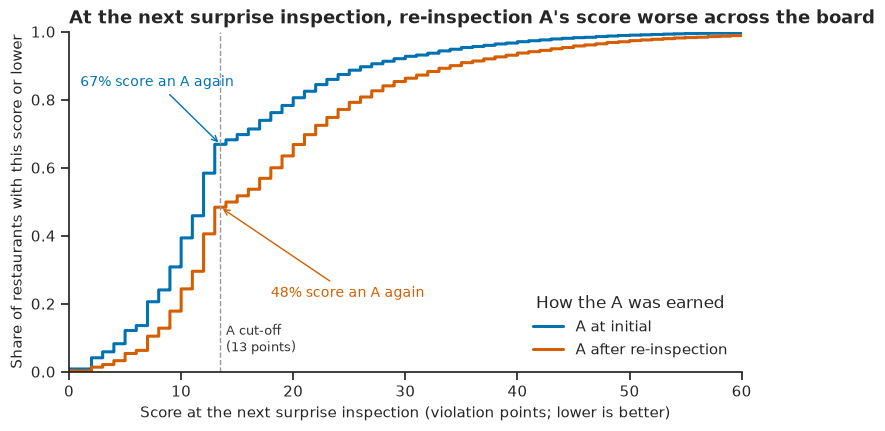

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), layout="constrained")
for route in ROUTES:
    sns.ecdfplot(data=followed[followed["route"] == route], x="next_score", ax=ax,
                 color=GROUP_COLORS[route], lw=2.2, label=route)
ax.axvline(A_MAX + .5, color=PALETTE["grey"], ls="--", lw=1)
ax.text(A_MAX + 1, 0.06, "A cut-off\n(13 points)", fontsize=9, color=PALETTE["dark"])
for route, xy_text in zip(ROUTES, [(1, .84), (18, .22)]):
    pass_rate = 1 - fail_sum.loc[route, "estimate"]
    ax.annotate(f"{pass_rate:.0%} score an A again", xy=(A_MAX + .5, pass_rate), xytext=xy_text,
                color=GROUP_COLORS[route], fontsize=10,
                arrowprops=dict(arrowstyle="->", color=GROUP_COLORS[route]))
ax.set_xlim(0, 60)
ax.set_xlabel("Score at the next surprise inspection (violation points; lower is better)")
ax.set_ylabel("Share of restaurants with this score or lower")
ax.set_title("At the next surprise inspection, re-inspection A's score worse across the board")
ax.legend(title="How the A was earned", frameon=False, loc="lower right")
save(fig, "fig3_next_score_ecdf")

## 4. Why? The initial score carries information the window card throws away

If the grade is a lossy summary, the **initial score** should predict the next inspection smoothly, with no jump at the A line.

In [10]:
bins = [-1, 5, 9, 11, 13, 17, 21, 27, 40, 200]
labels = ["0-5", "6-9", "10-11", "12-13", "14-17", "18-21", "22-27", "28-40", "41+"]
followed["initial_band"] = pd.cut(followed["initial_score"], bins, labels=labels)
band_sum, _ = cluster_bootstrap_means(followed, "next_fail", by="initial_band", B=B)
band_sum = band_sum.reindex(labels)
band_sum

,estimate,ci_low,ci_high,n_obs,n_restaurants
initial_band,,,,,
0-5,0.210871,0.198226,0.223547,4121,3660
6-9,0.306281,0.296062,0.317251,7356,6419
10-11,0.358448,0.346744,0.370840,6238,5593
12-13,0.392342,0.381519,0.402965,8383,7213
14-17,0.461516,0.444635,0.477841,3443,3126
18-21,0.495903,0.480524,0.510829,4027,3579
22-27,0.539311,0.523205,0.554991,3714,3302
28-40,0.551673,0.533522,0.570478,2719,2482
41+,0.591253,0.564666,0.619129,1189,1122


'/home/claude/p1/figures/fig4_initial_score_predicts_next.png'

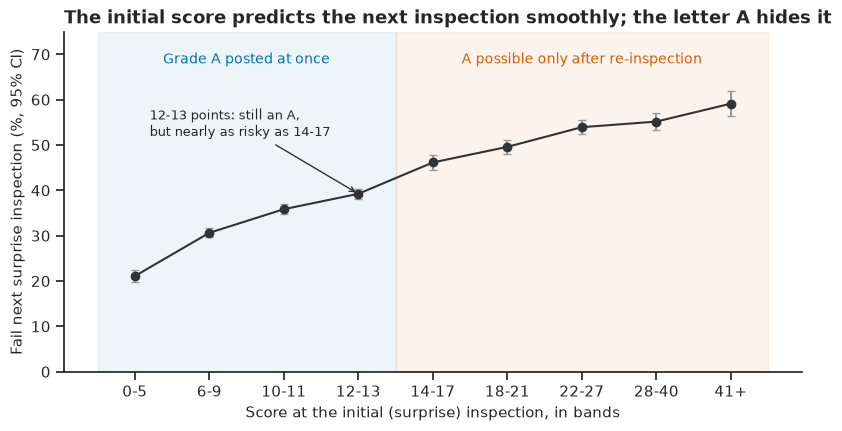

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2), layout="constrained")
x = np.arange(len(labels))
ax.axvspan(-.5, 3.5, color=PALETTE["blue"], alpha=.07)
ax.axvspan(3.5, len(labels) - .5, color=PALETTE["red"], alpha=.07)
ax.text(1.5, 68, "Grade A posted at once", ha="center", color=PALETTE["blue"], fontsize=10)
ax.text(6, 68, "A possible only after re-inspection", ha="center", color=PALETTE["red"], fontsize=10)
ax.errorbar(x, band_sum["estimate"] * 100,
            yerr=[(band_sum["estimate"] - band_sum["ci_low"]) * 100, (band_sum["ci_high"] - band_sum["estimate"]) * 100],
            fmt="o-", color=PALETTE["dark"], ecolor=PALETTE["grey"], capsize=3, ms=6)
ax.annotate("12-13 points: still an A,\nbut nearly as risky as 14-17",
            xy=(3, band_sum.loc["12-13", "estimate"] * 100), xytext=(0.2, 52),
            fontsize=9, arrowprops=dict(arrowstyle="->", color=PALETTE["dark"]))
ax.set_xticks(x, labels)
ax.set_ylim(0, 75)
ax.set_xlabel("Score at the initial (surprise) inspection, in bands")
ax.set_ylabel("Fail next surprise inspection (%, 95% CI)")
ax.set_title("The initial score predicts the next inspection smoothly; the letter A hides it")
save(fig, "fig4_initial_score_predicts_next")

The risk climbs steadily from about 1 in 5 (0-5 points) to about 3 in 5 (41+). There is **no cliff at 13/14**: the A line is a cut through a continuum. A restaurant that scored 12 and one that scored 30 then 10 on re-inspection both show the same card.

**Regression to the mean (honest note):** restaurants that scored badly the first time *do* improve on average (mean initial score 24.6 → next 18.7), partly because a bad first score includes some bad luck. But they don't improve all the way: their next score stays well above the first-time-A group (14.4).

## 5. Is it the same in every borough?

In [12]:
followed["cell"] = followed["boro"] + " | " + followed["route"].astype(str)
cell_sum, _ = cluster_bootstrap_means(followed, "next_fail", by="cell", B=B)
cell_sum[["boro", "route"]] = cell_sum.index.to_series().str.split(" \\| ", expand=True).to_numpy()
cell_sum[["estimate", "ci_low", "ci_high", "n_obs"]].round(3)

,estimate,ci_low,ci_high,n_obs
cell,,,,
BRONX | A after re-inspection,0.477,0.448,0.504,1252
BRONX | A at initial,0.318,0.301,0.336,2612
BROOKLYN | A after re-inspection,0.531,0.514,0.547,3790
BROOKLYN | A at initial,0.333,0.320,0.345,6207
MANHATTAN | A after re-inspection,0.528,0.516,0.541,6235
MANHATTAN | A at initial,0.347,0.338,0.356,10129
QUEENS | A after re-inspection,0.488,0.470,0.506,3267
QUEENS | A at initial,0.307,0.295,0.318,6309
STATEN ISLAND | A after re-inspection,0.540,0.495,0.584,548


'/home/claude/p1/figures/fig5_fail_rate_by_borough.png'

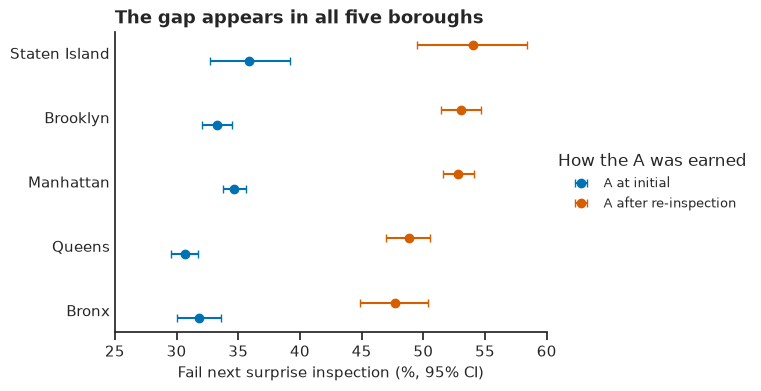

In [13]:
order = (cell_sum[cell_sum["route"] == "A after re-inspection"].sort_values("estimate")["boro"].tolist())
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
for route, offset in zip(ROUTES, [-.12, .12]):
    d = cell_sum[cell_sum["route"] == route].set_index("boro").loc[order]
    yv = np.arange(len(order)) + offset
    ax.errorbar(d["estimate"] * 100, yv,
                xerr=[(d["estimate"] - d["ci_low"]) * 100, (d["ci_high"] - d["estimate"]) * 100],
                fmt="o", color=GROUP_COLORS[route], capsize=3, ms=6, label=route)
ax.set_yticks(range(len(order)), [b.title() for b in order])
ax.set_xlim(25, 60)
ax.set_xlabel("Fail next surprise inspection (%, 95% CI)")
ax.set_title("The gap appears in all five boroughs")
ax.legend(title="How the A was earned", frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.tick_params(axis="y", length=0)
save(fig, "fig5_fail_rate_by_borough")

## 6. Context: scores pile up just under the A line

A known feature of NYC grades (FiveThirtyEight wrote about it in 2014): far more inspections land on 12-13 points than on 14-15. Points come in fixed amounts per violation, so the histogram is bumpy everywhere, but the drop at the cut-off is much larger than anywhere else.

In [14]:
scored = cyc[cyc["score"] <= 40]
counts = {k: scored[scored["kind"] == k]["score"].value_counts().sort_index()
          for k in ["Initial Inspection", "Re-inspection"]}
for k, c in counts.items():
    pair = lambda a, b: c.get(a, 0) + c.get(b, 0)
    print(f"{k:20s} 10-11: {pair(10,11):6,} | 12-13: {pair(12,13):6,} | 14-15: {pair(14,15):6,} | 16-17: {pair(16,17):6,}"
          f" -> 12-13 is {pair(12,13)/pair(14,15):.1f}x 14-15")

init = cyc[cyc["kind"] == "Initial Inspection"].assign(
    lo=lambda d: d["score"].between(12, 13).astype(float), hi=lambda d: d["score"].between(14, 15).astype(float))
s, draws = cluster_bootstrap_means(init.melt(id_vars="camis", value_vars=["lo", "hi"]), "value", by="variable", B=B)
ratio = draws["lo"] / draws["hi"]
ratio_est = s.loc["lo", "estimate"] / s.loc["hi", "estimate"]
print(f"Initial inspections: 12-13 points is {ratio_est:.1f}x as common as 14-15 "
      f"(95% CI {ratio.quantile(.025):.1f} to {ratio.quantile(.975):.1f})")

Initial Inspection   10-11:  9,581 | 12-13: 13,479 | 14-15:  2,285 | 16-17:  3,346 -> 12-13 is 5.9x 14-15
Re-inspection        10-11:  6,559 | 12-13:  9,362 | 14-15:    828 | 16-17:  1,017 -> 12-13 is 11.3x 14-15


Initial inspections: 12-13 points is 5.9x as common as 14-15 (95% CI 5.6 to 6.2)


'/home/claude/p1/figures/fig6_score_bunching_at_A_cutoff.png'

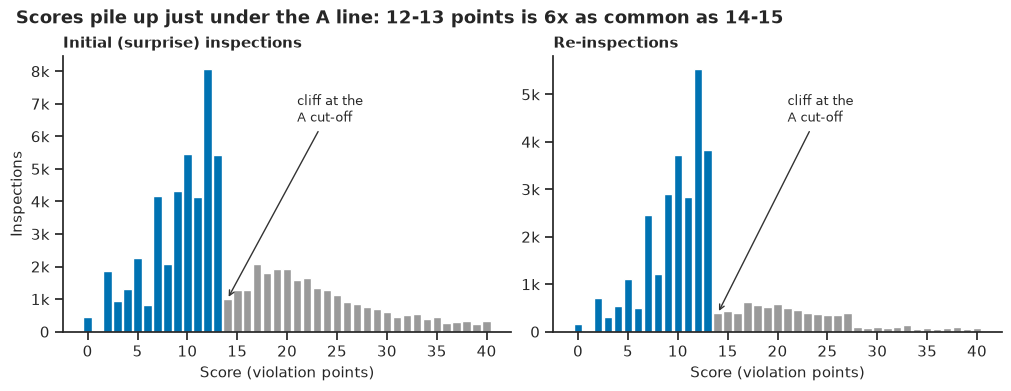

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), sharey=False, layout="constrained")
for ax, (k, c) in zip(axs, counts.items()):
    colors = [PALETTE["blue"] if s_ <= A_MAX else PALETTE["grey"] for s_ in c.index]
    ax.bar(c.index, c.values, color=colors, width=.85)
    ax.set_title(k.replace("Re-inspection", "Re-inspections").replace("Initial Inspection", "Initial (surprise) inspections"),
                 fontsize=11)
    ax.set_xlabel("Score (violation points)")
    top = c.loc[12:13].max()
    ax.annotate("cliff at the\nA cut-off", xy=(14, c.get(14, 0)), xytext=(21, top * .8), fontsize=9,
                arrowprops=dict(arrowstyle="->", color=PALETTE["dark"]))
    ax.yaxis.set_major_formatter(lambda v, pos: f"{v/1000:.0f}k" if v >= 1000 else f"{v:.0f}")
axs[0].set_ylabel("Inspections")
fig.suptitle(f"Scores pile up just under the A line: 12-13 points is {ratio_est:.0f}x as common as 14-15",
             x=0.01, ha="left", fontsize=13, weight="bold")
save(fig, "fig6_score_bunching_at_A_cutoff")

This doesn't prove inspectors round down (violations have fixed point values, and restaurants also work hard to stay under 14). But it means **an A is often a narrow pass**, which fits section 4.

## 7. Robustness checks

Does the main gap survive different choices?

In [16]:
def gap(df):
    s, d = cluster_bootstrap_means(df, "next_fail", by="route", B=1000)
    e = s.loc["A after re-inspection", "estimate"] - s.loc["A at initial", "estimate"]
    ci = diff_ci(d, "A after re-inspection", "A at initial", e)
    return pd.Series({"n": len(df), "fail_A_at_initial": s.loc["A at initial", "estimate"],
                      "fail_A_after_reinspection": s.loc["A after re-inspection", "estimate"],
                      "difference": e, "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})

followed["gap_band"] = pd.cut(followed["gap_days"], [0, 240, 420, 5000], labels=["< 8 months", "8-14 months", "> 14 months"])
checks = {
    "All A grades (main result)": followed,
    "First A per restaurant only": first,
    "A posted 2015-2016 (longer follow-up)": followed[followed["grade_date"] < "2017-01-01"],
    "Next inspection < 8 months later": followed[followed["gap_band"] == "< 8 months"],
    "Next inspection 8-14 months later": followed[followed["gap_band"] == "8-14 months"],
    "Next inspection > 14 months later": followed[followed["gap_band"] == "> 14 months"],
}
robust = pd.DataFrame({name: gap(df) for name, df in checks.items()}).T
robust["n"] = robust["n"].astype(int)
robust.round(3)

,n,fail_A_at_initial,fail_A_after_reinspection,difference,ci_low,ci_high
All A grades (main result),41190,0.331,0.516,0.185,0.175,0.194
First A per restaurant only,18825,0.322,0.514,0.192,0.178,0.207
A posted 2015-2016 (longer follow-up),22820,0.323,0.482,0.159,0.145,0.172
Next inspection < 8 months later,15560,0.449,0.519,0.070,0.050,0.091
Next inspection 8-14 months later,18865,0.318,0.521,0.203,0.182,0.225
Next inspection > 14 months later,6765,0.309,0.365,0.056,-0.000,0.112


The gap points the same way in every check. It is largest for the usual 8-14-month cycle (about 20 points) and much smaller when the next inspection comes either soon (< 8 months, about 7 points) or late (> 14 months, about 6 points). The > 14-month group is small (282 re-inspection A's) and its interval just touches zero, so on its own it is inconclusive. Timing clearly matters, which is why the README lists the city's inspection schedule as a limitation.

**A check that looks good but is biased (and why I don't use it):** comparing the two routes *within the same restaurant* flips the sign. That's an artefact: with only ~3.5 years of data, a restaurant only shows both routes if it alternates (an A at initial whose next surprise inspection failed, then an A after re-inspection followed by a pass). Selecting restaurants on that pattern selects on the outcome.

In [17]:
both = followed.groupby("camis")["route"].nunique()
within = followed[followed["camis"].isin(both[both == 2].index)]
print(f"Restaurants with both routes: {within['camis'].nunique():,}")
print(within.groupby("route", observed=True)["next_fail"].mean().round(3))

Restaurants with both routes: 7,370
route
A at initial             0.558
A after re-inspection    0.395
Name: next_fail, dtype: float64


## 8. Save the key numbers

In [18]:
key = {
    "n_inspections": int(len(inspections)),
    "n_restaurants": int(len(restaurants)),
    "n_A_grades": int(len(events)),
    "n_A_grades_followed": int(len(followed)),
    "n_restaurants_followed": int(followed["camis"].nunique()),
    "share_A_after_reinspection": share_all.loc["all", ["estimate", "ci_low", "ci_high"]].round(4).tolist(),
    "fail_next_A_at_initial": fail_sum.loc["A at initial", ["estimate", "ci_low", "ci_high"]].round(4).tolist(),
    "fail_next_A_after_reinspection": fail_sum.loc["A after re-inspection", ["estimate", "ci_low", "ci_high"]].round(4).tolist(),
    "fail_difference_pp": [round(100 * v, 1) for v in (fail_diff["estimate"], fail_diff["ci_low"], fail_diff["ci_high"])],
    "relative_risk": [round(rr_est, 2), round(rr.quantile(.025), 2), round(rr.quantile(.975), 2)],
    "next_score_A_at_initial": score_sum.loc["A at initial", ["estimate", "ci_low", "ci_high"]].round(2).tolist(),
    "next_score_A_after_reinspection": score_sum.loc["A after re-inspection", ["estimate", "ci_low", "ci_high"]].round(2).tolist(),
    "permutation_p_value_first_A": round(float(p_value), 5),
    "bunching_ratio_12_13_vs_14_15": [round(ratio_est, 2), round(ratio.quantile(.025), 2), round(ratio.quantile(.975), 2)],
}
(RESULTS / "key_numbers.json").write_text(json.dumps(key, indent=2))
robust.to_csv(RESULTS / "robustness_checks.csv")
print(json.dumps(key, indent=2))

{
  "n_inspections": 135864,
  "n_restaurants": 25744,
  "n_A_grades": 59896,
  "n_A_grades_followed": 41190,
  "n_restaurants_followed": 18825,
  "share_A_after_reinspection": [
    0.3105,
    0.3063,
    0.3148
  ],
  "fail_next_A_at_initial": [
    0.3313,
    0.3259,
    0.337
  ],
  "fail_next_A_after_reinspection": [
    0.5163,
    0.5084,
    0.5244
  ],
  "fail_difference_pp": [
    18.5,
    17.5,
    19.5
  ],
  "relative_risk": [
    1.56,
    1.52,
    1.59
  ],
  "next_score_A_at_initial": [
    14.4,
    14.28,
    14.53
  ],
  "next_score_A_after_reinspection": [
    18.65,
    18.45,
    18.86
  ],
  "permutation_p_value_first_A": 0.0001,
  "bunching_ratio_12_13_vs_14_15": [
    5.9,
    5.65,
    6.17
  ]
}


## Conclusion

**No — an A does not mean the same thing on both routes.** About **3 in 10** A grades were earned only after a failed surprise inspection. Those restaurants failed their **next** surprise inspection about **half the time (52%)**, against **one third (33%)** for restaurants that earned the A first time: a gap of **18.5 percentage points** (95% CI 17.5 to 19.5), **1.56 times** the risk. The gap appears in all five boroughs and points the same way in every robustness check, though it is much smaller when the next inspection comes unusually soon or late.

The reason is visible in figure 4: the initial score predicts the next inspection smoothly, and the letter grade throws that information away.

**What this does *not* show** (see the README's Limitations): it doesn't show that re-inspections are lax or that the grading system *causes* anything, and it can't say anything about actual food-borne illness. It is a statement about what the window card predicts.